<a href="https://colab.research.google.com/github/timuriz/ObjectSegmentationMarsWS25/blob/main/OSMWS25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATASET PREPARATION

In [ ]:
!pip install wandb -qq
!pip install -q wandb

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
from PIL import Image # Pillow Library
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.models.segmentation as models
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import wandb

In [ ]:
class RoadBaseDataset(Dataset):
    def __init__(self, images_dir, masks_dir):
        self.images_dir = images_dir
        self.masks_dir = masks_dir

        self.image_names = sorted(os.listdir(images_dir))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names[idx]
        img_path = os.path.join(self.images_dir, name)
        mask_path = os.path.join(self.masks_dir, name)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))
        return image, mask

In [ ]:
IMG_SIZE = 768

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.0625, 0.0625), rotate=(-45, 45), p=0.5, interpolation=1, mask_interpolation=0),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
    ToTensorV2()
])

class IndexedRoadDataset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        name = self.base_dataset.image_names[idx]

        img_path = os.path.join(self.base_dataset.images_dir, name)
        mask_path = os.path.join(self.base_dataset.masks_dir, name)

        if not os.path.isfile(mask_path):
            raise FileNotFoundError(f"Missing mask for image: {name} | expected: {mask_path}")
        if not os.path.isfile(img_path):
            raise FileNotFoundError(f"Missing image file: {name} | expected: {img_path}")
        try:
            image = np.array(Image.open(img_path).convert("RGB"))
        except Exception as e:
            raise RuntimeError(f"Failed to read image: {img_path} | Error: {e}")
        try:
            mask  = np.array(Image.open(mask_path).convert("L"))
        except Exception as e:
            raise RuntimeError(f"Failed to read mask: {mask_path} | Error: {e}")

        mask = mask.astype(np.int64)

        augmented = self.transform(image=image, mask=mask)
        image = augmented["image"].float()

        mask  = augmented["mask"].long()

        return image, mask

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import random

images_dir = "/content/drive/MyDrive/Machine Learning/images_last_clean_dataset"
masks_dir  = "/content/drive/MyDrive/Machine Learning/masks_dataset_last_clean_dataset"


base_dataset = RoadBaseDataset(images_dir, masks_dir)

print("len(base_dataset):", len(base_dataset))

img0, m0 = base_dataset[0]
print("base_dataset[0] image:", type(img0), img0.shape)
print("base_dataset[0] mask: ", type(m0),  m0.shape)

n = len(base_dataset)
n_train = int(0.7 * n)
n_val = int(0.20 * n)
n_test = n - n_train - n_val

indices = list(range(n))

random.seed(42)
random.shuffle(indices)

print("n_train: ", n_train)
print("n_val: ", n_val)
print("n_test: ", n_test)

train_indices = indices[:n_train]
val_indices   = indices[n_train:(n_train+n_val)]
test_indices   = indices[(n_train+n_val):]

print("train_indices:", train_indices)
print("val_indices:  ", val_indices)
print("test_indices:  ", test_indices)

train_ds = IndexedRoadDataset(base_dataset, train_indices, train_transform)
val_ds   = IndexedRoadDataset(base_dataset, val_indices,   val_transform)
test_ds = IndexedRoadDataset(base_dataset, test_indices, val_transform)

print("len(train_ds):", len(train_ds))
print("len(val_ds):  ", len(val_ds))
print("len(test_ds):  ", len(test_ds))

img1, m1 = train_ds[0]
print("train_ds[0] image:", img1.shape)
print("train_ds[0] mask: ", m1.shape)

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True

)
val_loader   = DataLoader(
    val_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

len(base_dataset): 674
base_dataset[0] image: <class 'numpy.ndarray'> (512, 512, 3)
base_dataset[0] mask:  <class 'numpy.ndarray'> (512, 512)
n_train:  471
n_val:  134
n_test:  69
train_indices: [441, 39, 404, 578, 190, 617, 184, 358, 2, 597, 266, 487, 430, 92, 158, 320, 556, 293, 458, 526, 528, 527, 351, 132, 86, 378, 494, 213, 255, 42, 308, 261, 383, 241, 628, 286, 138, 614, 290, 391, 648, 583, 600, 560, 185, 357, 279, 100, 176, 668, 312, 116, 14, 324, 8, 329, 555, 74, 136, 535, 502, 106, 443, 143, 490, 69, 400, 62, 636, 319, 525, 33, 341, 123, 346, 531, 656, 101, 64, 340, 510, 240, 607, 482, 396, 506, 174, 172, 118, 15, 533, 212, 272, 354, 596, 539, 287, 28, 150, 634, 13, 557, 96, 149, 398, 162, 325, 456, 230, 454, 554, 256, 91, 24, 193, 655, 471, 393, 222, 198, 187, 509, 415, 302, 598, 5, 481, 326, 177, 523, 649, 60, 23, 251, 515, 72, 311, 43, 478, 426, 303, 421, 113, 119, 282, 243, 307, 602, 619, 180, 140, 412, 77, 316, 629, 653, 265, 280, 489, 328, 550, 612, 294, 355, 625, 129, 4

In [ ]:
print("Base dataset size:", len(base_dataset))
print("Max index in train indices:", max(train_indices))
print("Max index in val indices:", max(val_indices))


Base dataset size: 674
Max index in train indices: 673
Max index in val indices: 672


In [ ]:
def visualize(**images) -> None:

    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(" ".join(name.split("_")).title())
        plt.imshow(image, vmin=0, vmax=10)
    plt.show()

In [ ]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):

        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)

        return tensor


unnorm = UnNormalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

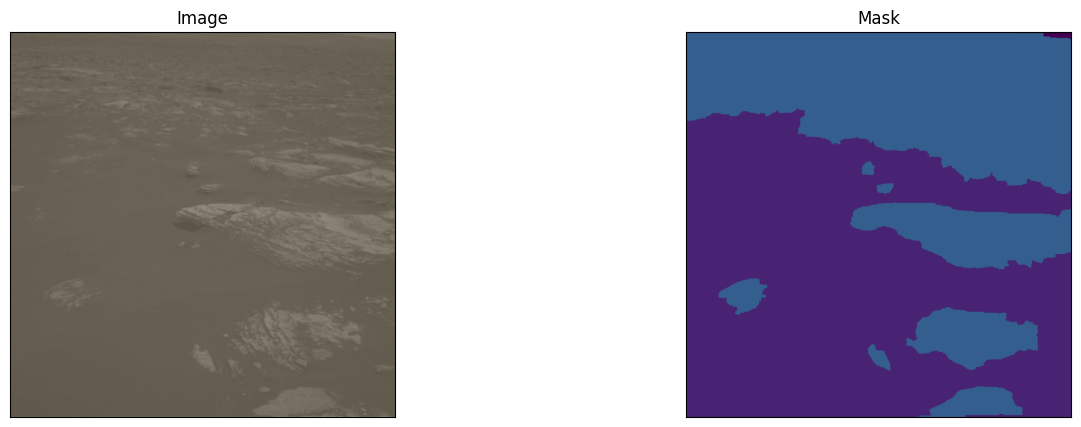

In [ ]:

idx = np.random.randint(len(train_ds))
image, mask = train_ds[idx]
visualize(image=unnorm(image).permute(1, 2, 0), mask=mask)

In [ ]:
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


# Model

In [ ]:
def create_model():
    # загружаем предобученную модель
    model = models.deeplabv3_resnet50(weights=models.DeepLabV3_ResNet50_Weights.DEFAULT)

    # заменяем финальный слой: 256 каналов -> 4 (для 4 классов)
    model.classifier[4] = nn.Conv2d(256, 4, kernel_size=1) # 256 output channels, 4 classes

    return model

model = create_model().to(device) # Moves the model’s parameters and buffers to the specified device

# TRAIN

In [ ]:
from tqdm.notebook import tqdm
import torch
import numpy as np # Add numpy import if not already present in this scope

def train_one_epoch(model, loader, optimizer, loss_fn, device, num_classes, ignore_index=0, class_ids=None):
    model.train()
    running_loss = 0.0

    if class_ids is None:
        class_ids = [c for c in range(num_classes) if c != ignore_index]

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    train_progress = tqdm(loader, colour="green")

    for images, masks in train_progress:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)["out"]          # (B, C, H, W)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)    # (B,H,W)
        cm = cm_update(cm, masks, preds, num_classes=num_classes, ignore_index=ignore_index)

    epoch_loss = running_loss / len(loader.dataset)
    metrics = metrics_from_cm(cm, class_ids=class_ids)

    train_miou = metrics["miou"]
    train_dice = metrics["mean_dice"]
    train_acc  = metrics["mean_class_acc"]

    return epoch_loss, train_miou, train_dice, train_acc

In [ ]:
def eval_one_epoch(model, val_loader, device, loss_fn, num_classes, ignore_index=0, class_ids=None):
    model.eval()

    if class_ids is None:
        class_ids = [c for c in range(num_classes) if c != ignore_index]

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)["out"]
            loss = loss_fn(logits, masks)

            total_loss += loss.item()
            n_batches += 1

            preds = torch.argmax(logits, dim=1)

            cm = cm_update(cm, masks, preds, num_classes=num_classes, ignore_index=ignore_index)

    avg_loss = total_loss / max(n_batches, 1)
    metrics = metrics_from_cm(cm, class_ids=class_ids)
    metrics["val_loss"] = avg_loss

    # after computing metrics from confusion matrix
    val_loss = avg_loss
    val_miou = metrics["miou"]
    val_dice = metrics["mean_dice"]
    val_acc  = metrics["mean_class_acc"]

    return val_loss, val_miou, val_dice, val_acc

# HyperParameters

In [ ]:
import torch.optim.lr_scheduler

cross_entropy_loss = nn.CrossEntropyLoss() # LogSoftmax to the model outputs, Negative Log-Likelihood loss

def loss_fn(outputs, masks):
    return cross_entropy_loss(outputs, masks)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4) # adapts the learning rate for each parameter using running averages of gradients
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) # creates a learning-rate scheduler that automatically reduces the learning rate when training stops improving

# EVALUATION


In [ ]:
import pandas as pd

metrics_history = {
    "epoch": [],
    "train_loss": [],
    "train_mIoU": [],
    "train_dice": [],
    "train_acc": [],
    "val_loss": [],
    "val_mIoU": [],
    "val_dice": [],
    "val_acc": [],
}


In [ ]:
checkpoints_dir = "checkpoints_patfinder"
os.makedirs(checkpoints_dir, exist_ok=True)

In [ ]:
def save_checkpoint(
    epoch,
    model,
    optimizer,
    scheduler,
    val_loss,
    path,
    artifact_name=None
):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "val_loss": val_loss,
    }

    torch.save(checkpoint, path)

    if artifact_name and wandb.run:
        artifact = wandb.Artifact(artifact_name, type='model')
        artifact.add_file(path)
        wandb.log_artifact(artifact)

In [ ]:
import numpy as np
import torch

def cm_update(cm, gt, pred, num_classes, ignore_index=0):
    """
    cm: numpy array (K,K)
    gt, pred: torch tensors (B,H,W) with class IDs
    """
    gt = gt.reshape(-1)
    pred = pred.reshape(-1)

    valid = (gt != ignore_index)
    gt = gt[valid]
    pred = pred[valid]

    k = num_classes
    idx = gt * k + pred
    bc = torch.bincount(idx, minlength=k*k).detach().cpu().numpy()
    cm += bc.reshape(k, k)
    return cm

In [ ]:
def metrics_from_cm(cm, class_ids):
    """
    cm: numpy array (K,K)
    class_ids: list like [1,2,3]
    """
    cm = cm.astype(np.float64)

    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    iou = {}
    dice = {}
    recall = {}

    for c in class_ids:
        denom_iou = tp[c] + fp[c] + fn[c]
        iou[c] = np.nan if denom_iou == 0 else tp[c] / denom_iou

        denom_dice = 2*tp[c] + fp[c] + fn[c]
        dice[c] = np.nan if denom_dice == 0 else (2*tp[c]) / denom_dice

        denom_rec = tp[c] + fn[c]
        recall[c] = np.nan if denom_rec == 0 else tp[c] / denom_rec

    miou = float(np.nanmean(list(iou.values())))
    mean_dice = float(np.nanmean(list(dice.values())))
    mean_class_acc = float(np.nanmean(list(recall.values())))

    # Pixel accuracy over evaluated classes+pixels is simply trace / sum
    pixel_acc = float(tp.sum() / cm.sum()) if cm.sum() > 0 else float("nan")

    return {
        "miou": miou,
        "iou_per_class": iou,
        "mean_dice": mean_dice,
        "dice_per_class": dice,
        "pixel_acc": pixel_acc,
        "mean_class_acc": mean_class_acc,
    }

# LAUNCH Train

In [ ]:
num_epochs = 40
num_classes = 4 # Defined based on the model output (model.classifier[4] = nn.Conv2d(256, 4, kernel_size=1))

In [ ]:
os.environ['WANDB_API_KEY'] = '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'
wandb.login()

# Initialize a new W&B run
wandb.init(
    project='Mars_Segmentation_Project',
    name="final-train-W&B",
    config={
        "num_classes_with_ignore": 4,
        "ignore_index": 0,
        "classes": {
            0: "ignore",
            1: "sand",
            2: "soil",
            3: "bedrock",
                    },
        'num_epochs': num_epochs,
        'IMG_SIZE': IMG_SIZE,
        'batch_size': train_loader.batch_size, # Taking batch_size from existing DataLoader
        'learning_rate': optimizer.param_groups[0]['lr']
    }
)
print("WandB initialized successfully.")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁█
learning_rate,▁▁
train_acc,▁█
train_dice,▁█
train_loss,█▁
train_mIoU,▁█
val_acc,█▁
val_dice,█▁
val_loss,█▁
val_mIoU,█▁
epoch,2


WandB initialized successfully.


In [ ]:
best_val_loss = float("inf") # initialized to the largest possible number

for epoch in range(num_epochs):
    train_loss, train_miou, train_dice, train_acc = train_one_epoch(
        model, train_loader, optimizer, loss_fn, device, num_classes
    )

    val_loss, val_miou, val_dice, val_acc = eval_one_epoch(
        model, val_loader, device, loss_fn, num_classes
    )

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | lr: {optimizer.param_groups[0]['lr']:.6f} \n"
        f"Train: loss={train_loss:.4f}, mIoU={train_miou:.4f}, Dice={train_dice:.4f}, Acc={train_acc:.4f}\n"
        f"Val: loss={val_loss:.4f}, mIoU={val_miou:.4f}, Dice={val_dice:.4f}, Acc={val_acc:.4f} \n"
    )

    # Log metrics to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_mIoU": train_miou,
        "train_dice": train_dice,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_mIoU": val_miou,
        "val_dice": val_dice,
        "val_acc": val_acc,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # Save the last checkpoint without creating an artifact for every epoch
    save_checkpoint(
        epoch=epoch + 1,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        val_loss=val_loss,
        path=os.path.join(checkpoints_dir, "checkpoints_last.pt")
    )


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            epoch=epoch + 1,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            val_loss=val_loss,
            path=os.path.join(checkpoints_dir, "checkpoints_best.pt"),
            artifact_name=f"best-model-epoch-{epoch+1}" # Log best model as W&B artifact
        )
        print("Best model saved")

    metrics_history["epoch"].append(epoch + 1)

    metrics_history["train_loss"].append(train_loss)
    metrics_history["train_mIoU"].append(train_miou)
    metrics_history["train_dice"].append(train_dice)
    metrics_history["train_acc"].append(train_acc)

    metrics_history["val_loss"].append(val_loss)
    metrics_history["val_mIoU"].append(val_miou)
    metrics_history["val_dice"].append(val_dice)
    metrics_history["val_acc"].append(val_acc)

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1/40 | lr: 0.000500 
Train: loss=0.8690, mIoU=0.3120, Dice=0.4663, Acc=0.4693
Val: loss=0.7589, mIoU=0.4318, Dice=0.5230, Acc=0.5810 

Best model saved


  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 2/40 | lr: 0.000500 
Train: loss=0.7397, mIoU=0.3922, Dice=0.5464, Acc=0.5555
Val: loss=0.5460, mIoU=0.6122, Dice=0.7551, Acc=0.7454 

Best model saved


  0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 38/40 | lr: 0.000063 
Train: loss=0.2542, mIoU=0.7943, Dice=0.8848, Acc=0.8797
Val: loss=0.2724, mIoU=0.7896, Dice=0.8812, Acc=0.8867 



  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 39/40 | lr: 0.000063 
Train: loss=0.2253, mIoU=0.8182, Dice=0.8995, Acc=0.8951
Val: loss=0.2523, mIoU=0.8189, Dice=0.8997, Acc=0.8956 

Best model saved


  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 40/40 | lr: 0.000063 
Train: loss=0.2341, mIoU=0.8129, Dice=0.8963, Acc=0.8918
Val: loss=0.2666, mIoU=0.8024, Dice=0.8895, Acc=0.8861 



In [ ]:
df = pd.DataFrame(metrics_history)

df.to_csv("metrics.csv", index=False)
print("Metrics saved to training_metrics.csv")


Metrics saved to training_metrics.csv


In [ ]:
PRED_DIR = "predictions_masks"
os.makedirs(PRED_DIR, exist_ok=True)

In [ ]:
import matplotlib.pyplot as plt
import cv2

@torch.no_grad()
def visualize_sample(
    model,
    dataset,
    idx=0,
    device=device,
    threshold=0.0, # Threshold for filtering low-confidence pixels in multi-class prediction
    save_dir=None
):
    model.eval()
    image, mask_true = dataset[idx] # mask_true is (H, W) with class indices
    image_batch = image.unsqueeze(0).to(device)

    output = model(image_batch)["out"]  # [1, C, H, W] where C=4

    # Apply softmax to get probabilities for each class
    softmax_output = torch.softmax(output, dim=1) # (1, 4, H, W)

    # Get the predicted class for each pixel
    pred_classes = torch.argmax(softmax_output, dim=1) # (1, H, W)
    # Get the probability of the predicted class for each pixel
    pred_probs, _ = torch.max(softmax_output, dim=1) # (1, H, W)

    # Convert to numpy
    pred_mask_np = pred_classes[0].cpu().numpy()
    pred_probs_np = pred_probs[0].cpu().numpy()

    # Apply threshold: set pixels with confidence below threshold to class 0 (background/unclassified)
    pred_mask_np[pred_probs_np < threshold] = 0

    if save_dir is not None:
        # Recover original filename
        base_name = dataset.base_dataset.image_names[dataset.indices[idx]]
        save_path = os.path.join(save_dir, base_name)

        # Save as PNG
        cv2.imwrite(save_path, pred_mask_np.astype(np.uint8))


    # in numpy
    img_np = image.permute(1,2,0).cpu().numpy()
    img_vis = img_np * 0.5 + 0.5        # return to [0,1] range
    img_vis = np.clip(img_vis, 0, 1)

    true_np = mask_true.cpu().numpy() # mask_true is already (H, W)

    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    axs[0].imshow(img_vis)
    axs[0].set_title("Image")
    # Using 'viridis' colormap for multi-class masks
    axs[1].imshow(true_np, cmap="viridis", vmin=0, vmax=3)
    axs[1].set_title("True mask")
    axs[2].imshow(pred_mask_np, cmap="viridis", vmin=0, vmax=3)
    axs[2].set_title(f"Pred mask (Threshold: {threshold:.2f})") # Show applied threshold
    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# User-definable threshold for pixel-wise confidence in predicted mask
visualization_threshold = 0.51 # Only show predicted class for pixels with confidence >= 0.5

for i in range(len(test_ds)):
    print(f"Sample {i}")
    visualize_sample(
        model,
        test_ds,
        idx=i,
        threshold=visualization_threshold,
        save_dir=PRED_DIR
    )

print(f"Prediction masks saved to: {PRED_DIR}")